## Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


## Load Dataset


In [22]:
df  = pd.read_csv('iris.csv')
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [18]:
X = df.drop('variety', axis=1)
y = df['variety']

X.head(10)

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [19]:
df.isnull().sum()

,0
sepal.length,0
sepal.width,0
petal.length,0
petal.width,0
variety,0


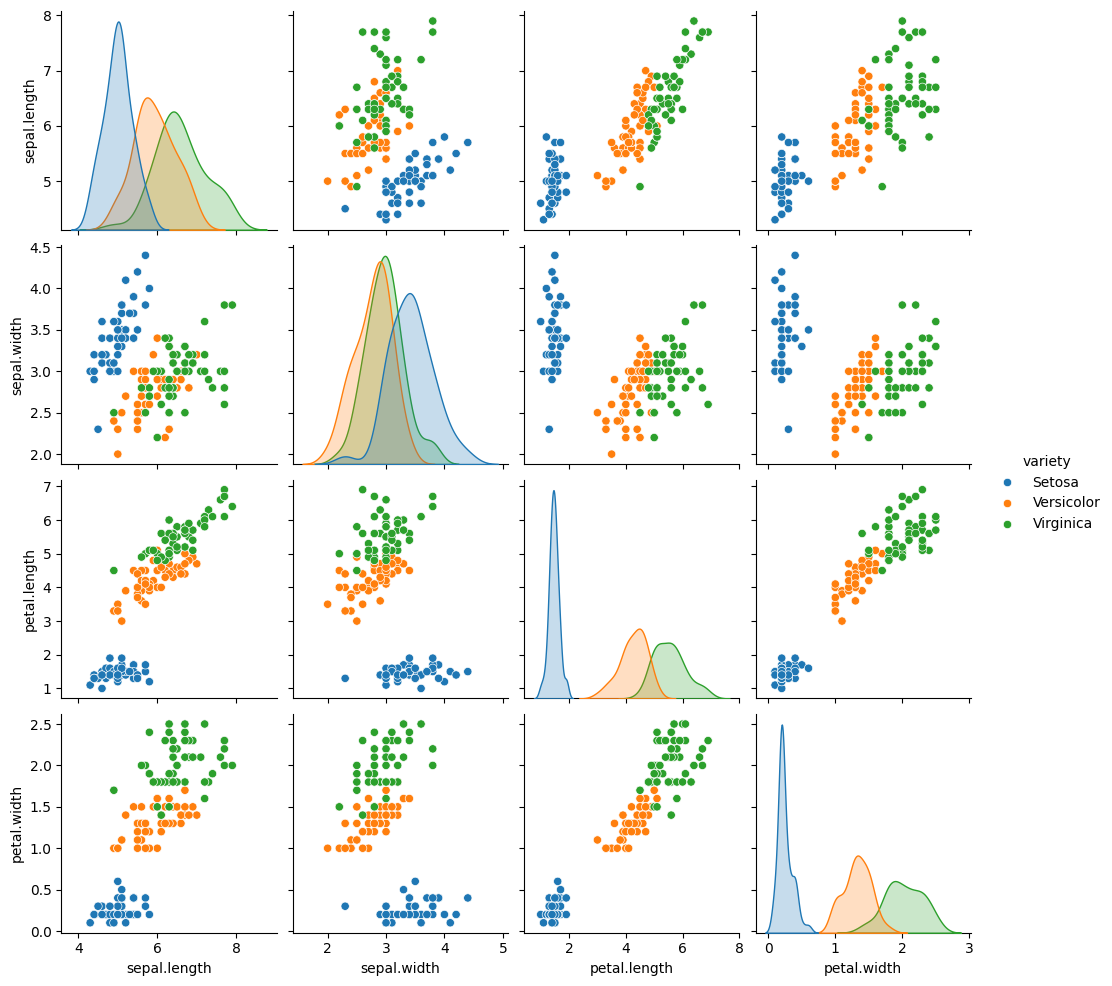

In [35]:
sns.pairplot(df, hue='variety')
plt.show()

## Corelation Heatmap

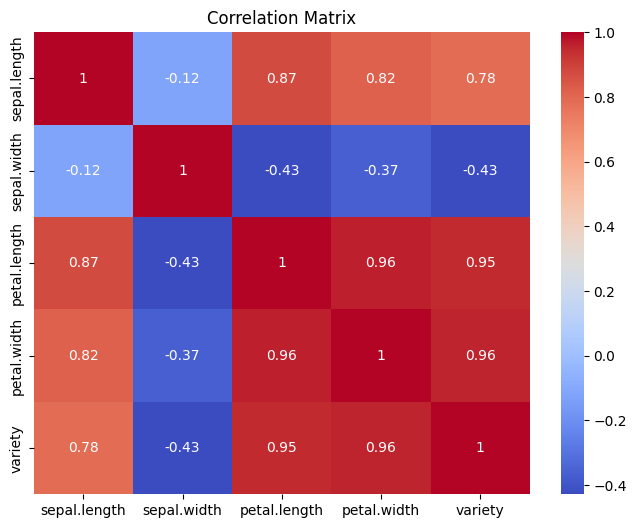

In [36]:
df_heat = df.copy()

df_heat['variety'] = df_heat['variety'].astype('category').cat.codes

plt.figure(figsize=(8,6))

sns.heatmap(
    df_heat.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# Distribution

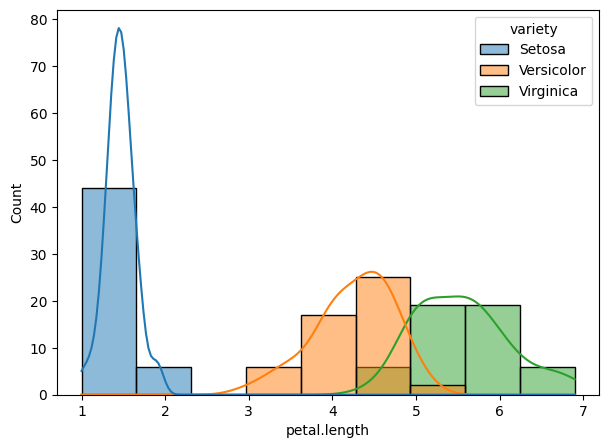

In [37]:
sns.histplot(
    data=df,
    x='petal.length',
    hue='variety',
    kde=True
)

plt.show()

## Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2,
                                                 random_state = 42, stratify=y)
print(X_train)
print(X_test)

     sepal.length  sepal.width  petal.length  petal.width
8             4.4          2.9           1.4          0.2
106           4.9          2.5           4.5          1.7
76            6.8          2.8           4.8          1.4
9             4.9          3.1           1.5          0.1
89            5.5          2.5           4.0          1.3
..            ...          ...           ...          ...
37            4.9          3.6           1.4          0.1
2             4.7          3.2           1.3          0.2
33            5.5          4.2           1.4          0.2
52            6.9          3.1           4.9          1.5
3             4.6          3.1           1.5          0.2

[120 rows x 4 columns]
     sepal.length  sepal.width  petal.length  petal.width
38            4.4          3.0           1.3          0.2
127           6.1          3.0           4.9          1.8
57            4.9          2.4           3.3          1.0
93            5.0          2.3           3.3    

## Decision Tree

In [39]:
tree_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [46]:
y_pred = tree_model.predict(X_test)
print(y_pred)

['Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa' 'Versicolor'
 'Setosa' 'Setosa' 'Virginica' 'Versicolor' 'Virginica' 'Virginica'
 'Virginica' 'Versicolor' 'Setosa' 'Setosa' 'Setosa' 'Versicolor'
 'Versicolor' 'Virginica' 'Setosa' 'Virginica' 'Versicolor' 'Virginica'
 'Virginica' 'Virginica' 'Versicolor' 'Setosa' 'Virginica' 'Setosa']


## Accuracy Score

In [47]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


In [48]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


## Visualize

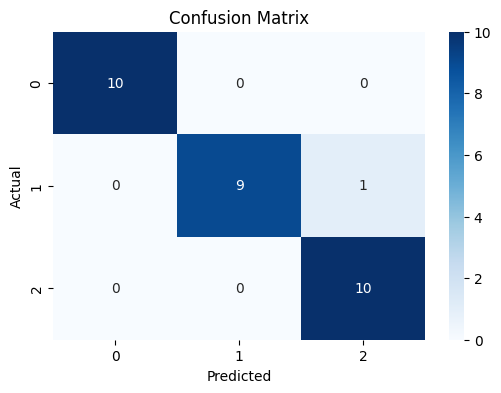

In [49]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Classification Report

In [50]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Feature Importance and Plot

        Feature  Importance
2  petal.length    0.686546
3   petal.width    0.313454
1   sepal.width    0.000000
0  sepal.length    0.000000


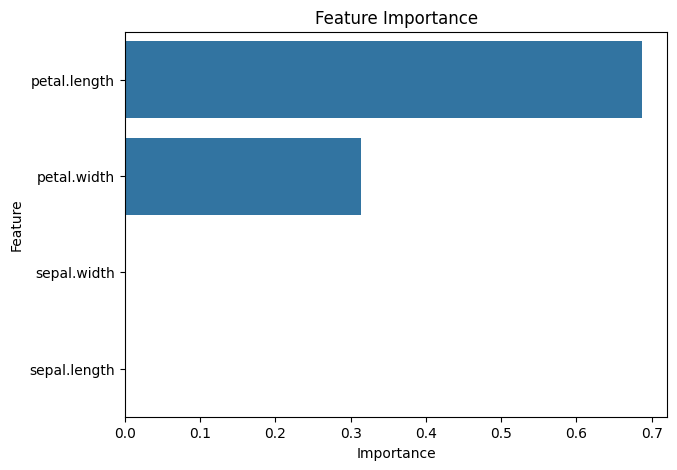

In [51]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':tree_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

## Visualize Decision Tree

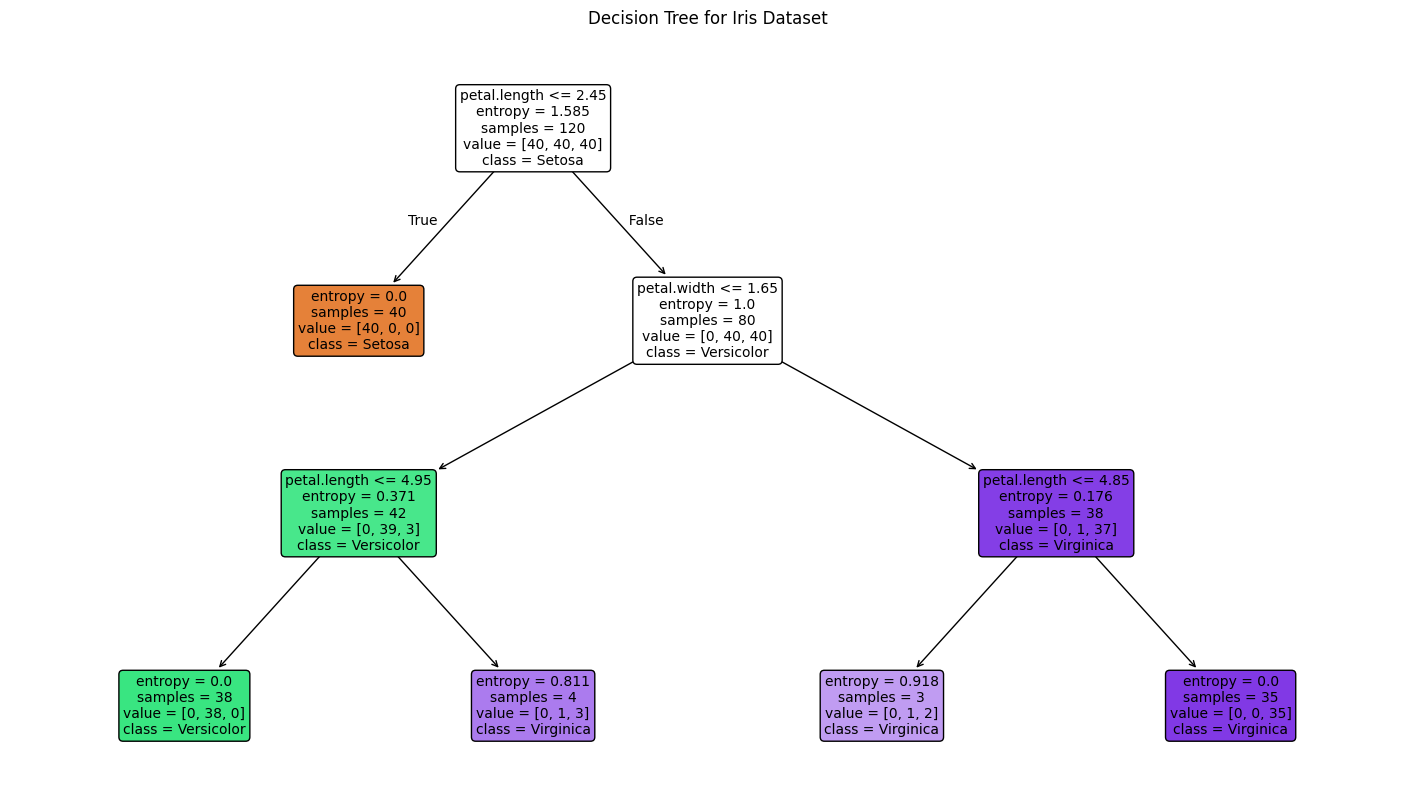

In [52]:
plt.figure(figsize=(18,10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Iris Dataset")
plt.show()

## New Prediction

In [53]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = tree_model.predict(sample)

print(prediction)

['Setosa']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
